DATA READY
n = 3408
d = 9

PART III(a): Z-SCORE
Mean = 8.285714285714286
ML standard deviation = 7.591617288906527
z-score of 25 = 2.201676543772821
|z| > 3 ? False

PART III(a): LOF WARM-UP
 stall  dist2          N2     lrd2     LOF2
   1.0    2.0  [2.0, 3.0] 0.666667 0.875000
   2.0    1.0  [1.0, 3.0] 0.500000 1.333333
   3.0    2.0  [1.0, 2.0] 0.666667 0.875000
   8.0    2.0 [9.0, 10.0] 0.666667 0.875000
   9.0    1.0 [8.0, 10.0] 0.500000 1.333333
  10.0    2.0  [8.0, 9.0] 0.666667 0.875000
  25.0   16.0 [9.0, 10.0] 0.064516 9.041667

Top LOF outlier: 25.0

COMPUTING kNN20
Done.

COMPUTING LOF20
Done.

LOF VERIFICATION
Maximum absolute difference: 1.0928813409805116e-10
Required tolerance: 1e-8
PASS: True

LOF20 > 1.5
Number of tracks: 38
Maximum LOF20: 2.569334186674885

TOP 5 LOF TRACKS
 Rank                                                                    Track                                                                          Artist     Genre    LOF20
    1 12 Variations

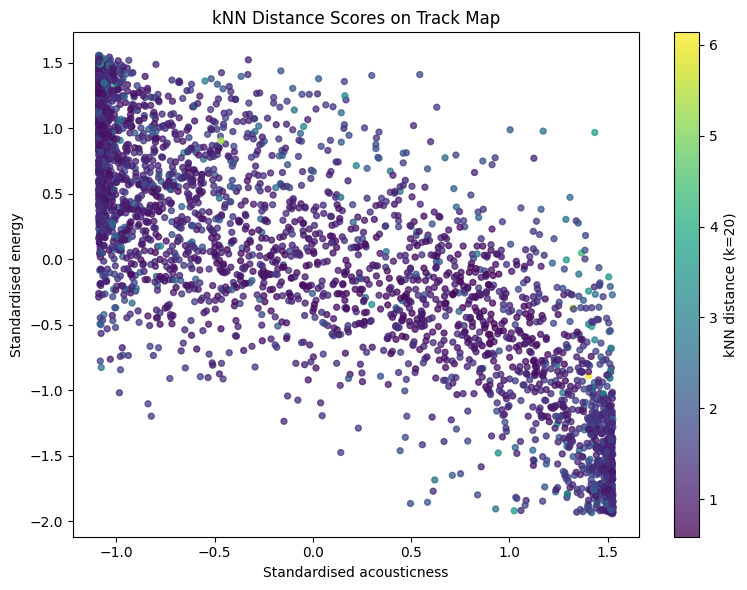

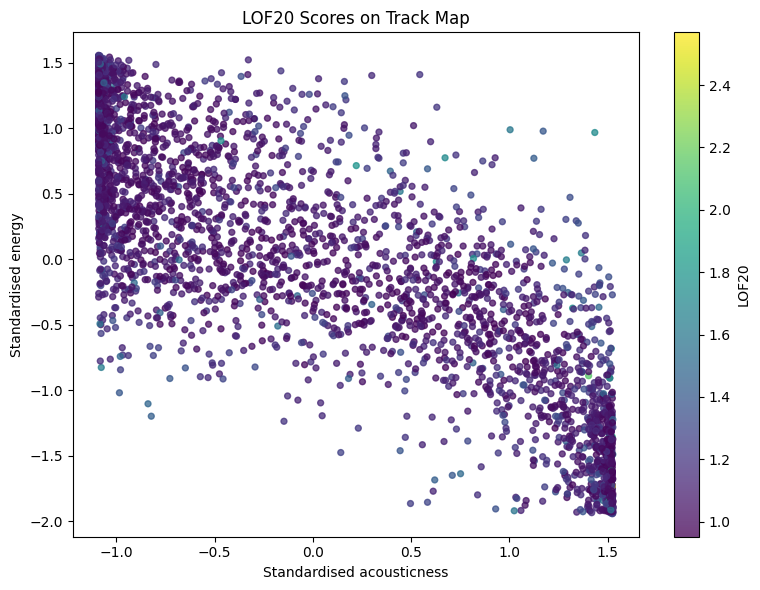

BEST k=4
Seed: 3
SSE: 15811.389037790766

DBSCAN
Number of clusters: 1
Number of noise points: 55

OVERLAP WITH DBSCAN
        Detector  Overlap with DBSCAN noise  m
    kNN distance                         46 55
           LOF20                         24 55
Clustering-based                         33 55
Isolation Forest                         30 55



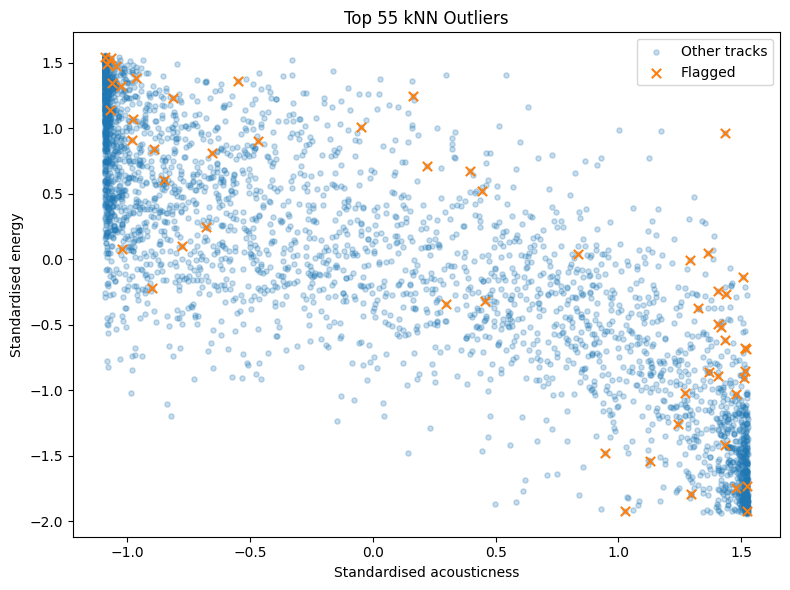

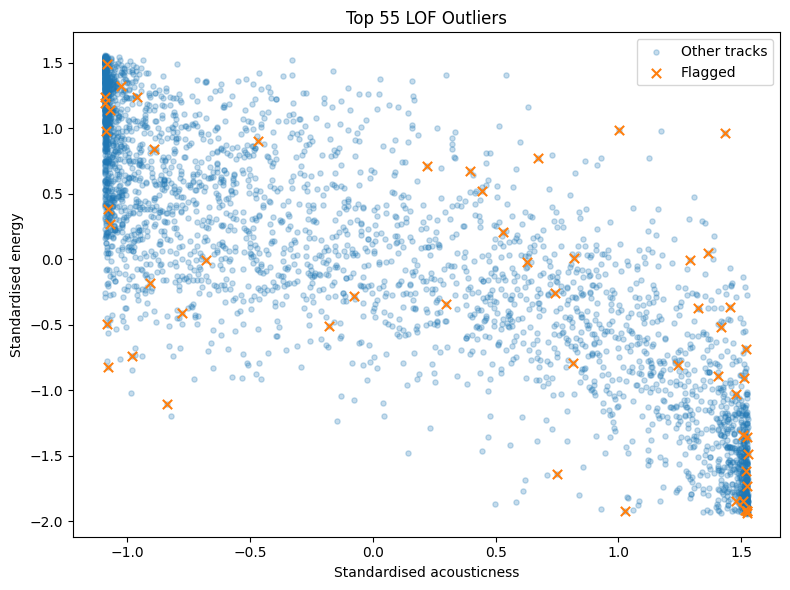

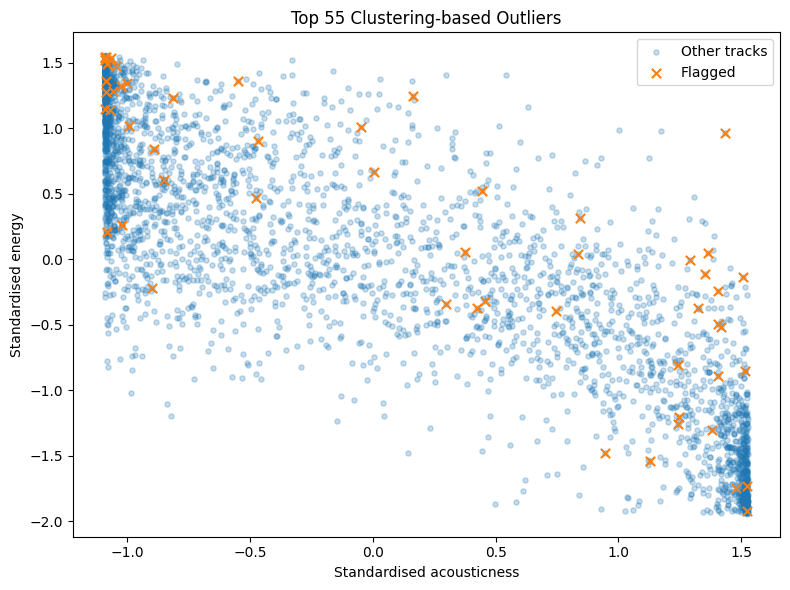

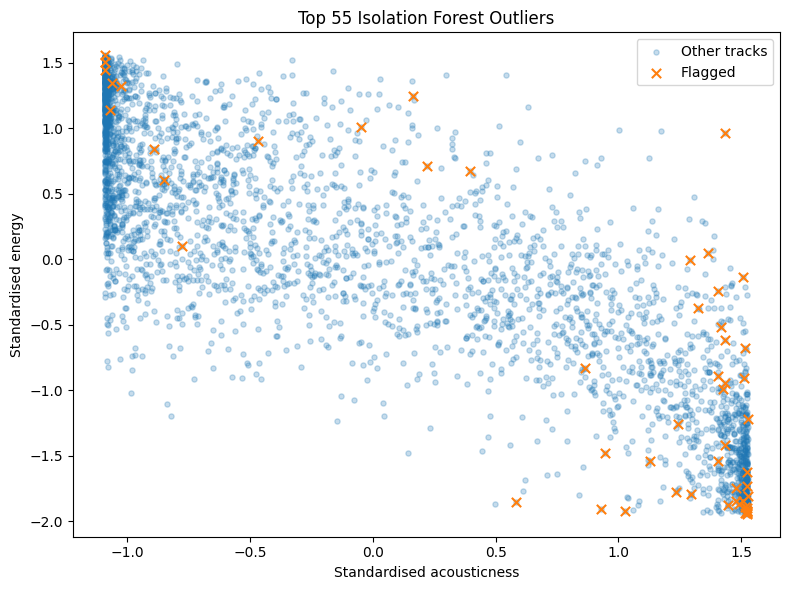

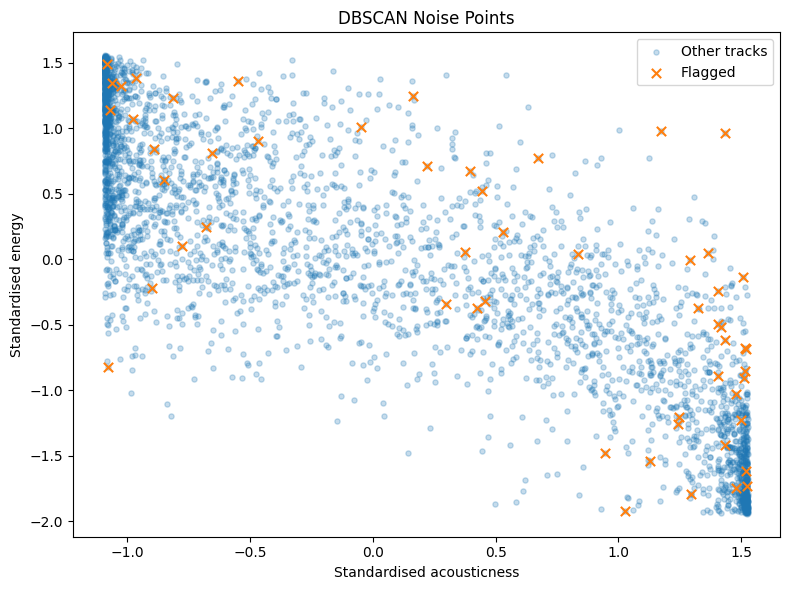

DBSCAN NOISE TRACKS
                                                              track_name                                                                         artists track_genre    LOF20    kNN20
12 Variations on ‘La belle Françoise’ in E flat, K.353: 8. Variation VII                                          Wolfgang Amadeus Mozart;Danielle Laval   classical 2.569334 4.309204
                                               Sri Venkatesa Suprabhatam                                 M. S. Subbulakshmi;T. K. Murthy;V.V.Subramaniam   classical 2.139969 6.138221
                        2 Canons in F for 2 voices in 1, K508a: Nos. 1-2 Wolfgang Amadeus Mozart;Karl-Heinz Steffens;Werner Mittelbach;Joachim Olszewski   classical 1.926843 2.672696
                                                          Vettri Venduma                                                           Sirkazhi Govindarajan   classical 1.806581 3.145068
             Concerto for 2 Cellos in G Minor, RV 531: I. Allegro

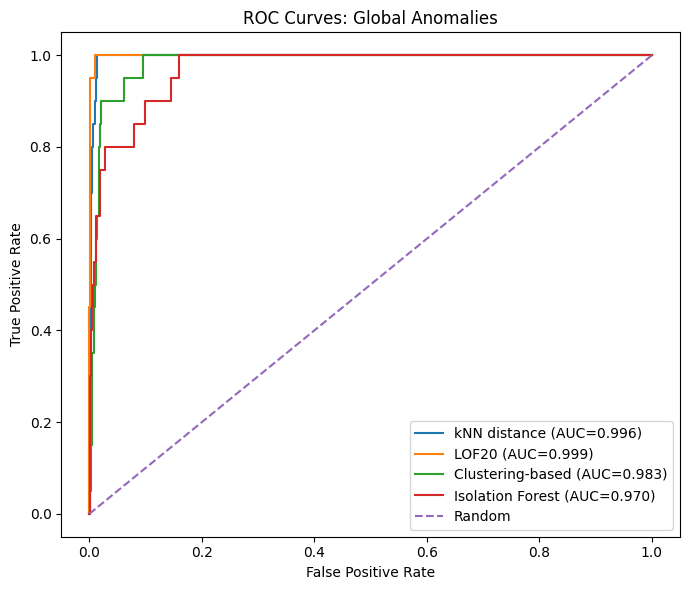

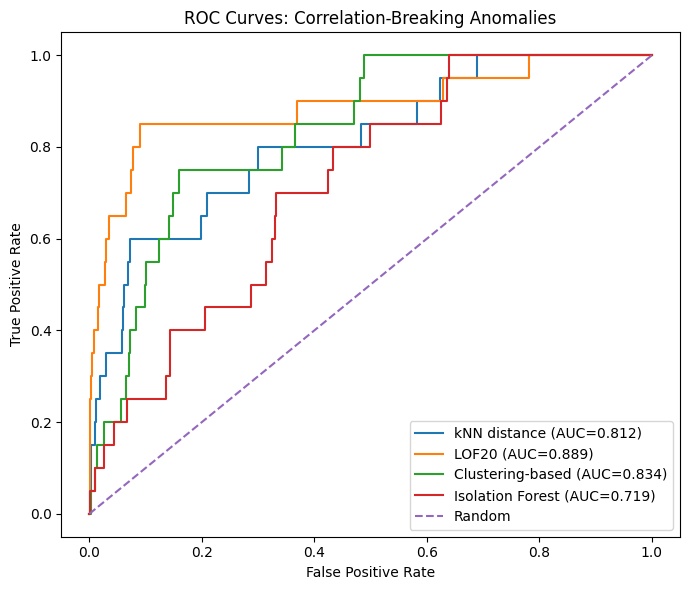

WHY ACCURACY IS MISLEADING
Normal observations: 3408
Injected anomalies: 20
Total: 3428
Accuracy from predicting EVERY point as normal: 0.9941656942823804

PART III SANITY CHECKS
LOF20 > 1.5 count: 38
Largest original LOF20: 2.569334186674885

Original DBSCAN clusters: 1
Original DBSCAN noise points: 55

Global ROC AUCs:
kNN distance : 0.9961
LOF20 : 0.9993
Clustering-based : 0.9832
Isolation Forest : 0.9698

Correlation-breaking ROC AUCs:
kNN distance : 0.8117
LOF20 : 0.8886
Clustering-based : 0.834
Isolation Forest : 0.7189

Global DBSCAN injected anomalies detected: 20 / 20

PART III COMPLETE
Generated files:
 - part3b_top5_lof.csv
 - part3b_knn_track_map.png
 - part3b_lof_track_map.png
 - part3c_dbscan_overlap.csv
 - part3c_knn_top_m.png
 - part3c_lof_top_m.png
 - part3c_cluster_top_m.png
 - part3c_isolation_top_m.png
 - part3c_dbscan_noise.png
 - part3c_dbscan_noise_tracks.csv
 - part3d_scoring_evaluation.csv
 - part3d_dbscan_evaluation.csv
 - part3d_roc_global.png
 - part3d_roc_c

In [1]:
# ============================================================
# Machine Learning - Assignment 1
# Part III: Outlier Detection
# ============================================================

# If Colab cannot read hf:// URLs, uncomment:
# !pip -q install huggingface_hub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)

# ============================================================
# 0. SETTINGS
# ============================================================

FEATURES = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

GENRES = [
    "classical",
    "hip-hop",
    "mandopop",
    "metal",
]

K_LOF = 20
MAX_ITER = 20


# ============================================================
# 1. LOAD + PREPARE DATA
# Same preprocessing as Part II
# ============================================================

url = "hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv"

df = pd.read_csv(url)

data = df[
    df["track_genre"].isin(GENRES)
].copy()

# Duplicate track ID removal
data = data.drop_duplicates(
    subset="track_id",
    keep="first"
)

# Duplicate feature vector removal
data = data.drop_duplicates(
    subset=FEATURES,
    keep="first"
)

data = data.reset_index(drop=True)

assert len(data) == 3408, (
    f"Expected 3408 tracks, got {len(data)}"
)

X = data[FEATURES].to_numpy(dtype=float)

mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=0)

Z = (X - mu) / sigma

n, d = Z.shape

print("=" * 70)
print("DATA READY")
print("=" * 70)
print("n =", n)
print("d =", d)
print()


# ============================================================
# PART III(a)
# WARM-UP BY HAND
# ============================================================

STALLS = np.array(
    [1, 2, 3, 8, 9, 10, 25],
    dtype=float
)

print("=" * 70)
print("PART III(a): Z-SCORE")
print("=" * 70)

stall_mean = STALLS.mean()

# Maximum likelihood estimate:
# divide by n, i.e. ddof=0
stall_std = STALLS.std(ddof=0)

z_25 = (
    25 - stall_mean
) / stall_std

print("Mean =", stall_mean)
print("ML standard deviation =", stall_std)
print("z-score of 25 =", z_25)
print("|z| > 3 ?", abs(z_25) > 3)
print()


# ============================================================
# 2. PAIRWISE DISTANCE MATRIX
# Memory-efficient formula required by assignment
# ============================================================

def pairwise_distances_numpy(X):
    """
    Compute Euclidean pairwise distance matrix using

        ||a-b||^2
        = ||a||^2 + ||b||^2 - 2 a^T b

    rather than broadcasting an n x n x d array.
    """

    X = np.asarray(X, dtype=float)

    sq_norm = np.sum(
        X * X,
        axis=1
    )

    D2 = (
        sq_norm[:, None]
        + sq_norm[None, :]
        - 2.0 * (X @ X.T)
    )

    # Floating point protection
    D2 = np.maximum(D2, 0.0)

    D = np.sqrt(D2)

    return D


# ============================================================
# 3. kNN SCORE FROM SCRATCH
# ============================================================

def knn_score(X, k):
    """
    Return distance to kth nearest neighbour
    for every observation.

    Self is excluded.
    """

    X = np.asarray(X, dtype=float)

    D = pairwise_distances_numpy(X)

    # Exclude self
    np.fill_diagonal(D, np.inf)

    # kth smallest distance:
    # partition index k-1
    kth = np.partition(
        D,
        kth=k - 1,
        axis=1
    )[:, k - 1]

    return kth


# ============================================================
# 4. LOF FROM SCRATCH
# ============================================================

def lof(X, k):
    """
    Local Outlier Factor implemented from scratch.

    Returns
    -------
    lof_scores : shape (n,)
    """

    X = np.asarray(X, dtype=float)

    n = X.shape[0]

    # Pairwise Euclidean distance matrix
    D = pairwise_distances_numpy(X)

    # Exclude self for neighbour selection
    D_no_self = D.copy()
    np.fill_diagonal(
        D_no_self,
        np.inf
    )

    # --------------------------------------------------------
    # Find exact k nearest neighbours
    # --------------------------------------------------------

    # argpartition finds k nearest indices without full sort
    neighbour_idx = np.argpartition(
        D_no_self,
        kth=k - 1,
        axis=1
    )[:, :k]

    # --------------------------------------------------------
    # dist_k(o)
    # --------------------------------------------------------

    kth_dist = np.partition(
        D_no_self,
        kth=k - 1,
        axis=1
    )[:, k - 1]

    # --------------------------------------------------------
    # Distances from each observation to its neighbours
    # --------------------------------------------------------

    row_idx = np.arange(n)[:, None]

    neighbour_distances = D[
        row_idx,
        neighbour_idx
    ]

    # dist_k(o') for every neighbour o'
    neighbour_kdist = kth_dist[
        neighbour_idx
    ]

    # --------------------------------------------------------
    # reach_k(o <- o')
    #
    # max(dist_k(o'), d(o,o'))
    # --------------------------------------------------------

    reachability = np.maximum(
        neighbour_kdist,
        neighbour_distances
    )

    # --------------------------------------------------------
    # Local reachability density
    #
    # inverse mean reachability distance
    # --------------------------------------------------------

    mean_reachability = (
        reachability.mean(axis=1)
    )

    lrd = 1.0 / mean_reachability

    # --------------------------------------------------------
    # LOF
    #
    # mean neighbour lrd / own lrd
    # --------------------------------------------------------

    neighbour_lrd = lrd[
        neighbour_idx
    ]

    lof_scores = (
        neighbour_lrd.mean(axis=1)
        / lrd
    )

    return lof_scores


# ============================================================
# 5. WARM-UP LOF k=2
# ============================================================

print("=" * 70)
print("PART III(a): LOF WARM-UP")
print("=" * 70)

stall_X = STALLS.reshape(-1, 1)

stall_D = pairwise_distances_numpy(
    stall_X
)

stall_D_no_self = stall_D.copy()
np.fill_diagonal(
    stall_D_no_self,
    np.inf
)

k = 2

stall_neighbour_idx = np.argpartition(
    stall_D_no_self,
    kth=k - 1,
    axis=1
)[:, :k]

stall_kdist = np.partition(
    stall_D_no_self,
    kth=k - 1,
    axis=1
)[:, k - 1]

row_idx = np.arange(
    len(STALLS)
)[:, None]

stall_neighbour_dist = stall_D[
    row_idx,
    stall_neighbour_idx
]

stall_neighbour_kdist = stall_kdist[
    stall_neighbour_idx
]

stall_reach = np.maximum(
    stall_neighbour_kdist,
    stall_neighbour_dist
)

stall_lrd = 1.0 / (
    stall_reach.mean(axis=1)
)

stall_lof = (
    stall_lrd[
        stall_neighbour_idx
    ].mean(axis=1)
    / stall_lrd
)

stall_table = []

for i, x in enumerate(STALLS):

    neighbours = STALLS[
        stall_neighbour_idx[i]
    ]

    stall_table.append({
        "stall": x,
        "dist2": stall_kdist[i],
        "N2": str(
            sorted(
                neighbours.tolist()
            )
        ),
        "lrd2": stall_lrd[i],
        "LOF2": stall_lof[i]
    })

stall_table = pd.DataFrame(
    stall_table
)

print(
    stall_table.to_string(
        index=False
    )
)

print()

top_stall = stall_table.loc[
    stall_table["LOF2"].idxmax()
]

print(
    "Top LOF outlier:",
    top_stall["stall"]
)

print()


# ============================================================
# 6. COMPUTE kNN20 AND LOF20
# ============================================================

print("=" * 70)
print("COMPUTING kNN20")
print("=" * 70)

knn20 = knn_score(
    Z,
    k=20
)

print("Done.")

print()
print("=" * 70)
print("COMPUTING LOF20")
print("=" * 70)

lof20 = lof(
    Z,
    k=20
)

print("Done.")
print()


# ============================================================
# 7. VERIFY LOF AGAINST SKLEARN
# ============================================================

print("=" * 70)
print("LOF VERIFICATION")
print("=" * 70)

sk_lof = LocalOutlierFactor(
    n_neighbors=20,
    metric="euclidean"
)

sk_lof.fit_predict(Z)

# sklearn stores NEGATED LOF
sk_lof_scores = (
    -sk_lof.negative_outlier_factor_
)

max_difference = np.max(
    np.abs(
        lof20
        - sk_lof_scores
    )
)

print(
    "Maximum absolute difference:",
    max_difference
)

print(
    "Required tolerance: 1e-8"
)

print(
    "PASS:",
    max_difference < 1e-8
)

print()


# ============================================================
# 8. DUPLICATE EXPLANATION SUPPORT
# ============================================================

# Exact duplicate points can cause zero distances.
# If a point and all required neighbours have zero
# reachability distance, local reachability density
# can become infinite / undefined.


# ============================================================
# 9. NUMBER OF TRACKS LOF > 1.5
# ============================================================

n_lof_15 = np.sum(
    lof20 > 1.5
)

print("=" * 70)
print("LOF20 > 1.5")
print("=" * 70)

print(
    "Number of tracks:",
    n_lof_15
)

print(
    "Maximum LOF20:",
    lof20.max()
)

print()


# ============================================================
# 10. TOP 5 LOF TRACKS
# ============================================================

top5_idx = np.argsort(
    lof20
)[-5:][::-1]

top5_lof = pd.DataFrame({
    "Rank": np.arange(1, 6),

    "Track": data.loc[
        top5_idx,
        "track_name"
    ].to_numpy(),

    "Artist": data.loc[
        top5_idx,
        "artists"
    ].to_numpy(),

    "Genre": data.loc[
        top5_idx,
        "track_genre"
    ].to_numpy(),

    "LOF20": lof20[
        top5_idx
    ]
})

print("=" * 70)
print("TOP 5 LOF TRACKS")
print("=" * 70)

print(
    top5_lof.to_string(
        index=False
    )
)

top5_lof.to_csv(
    "part3b_top5_lof.csv",
    index=False
)

print()


# ============================================================
# 11. TRACK MAP SETTINGS
# ============================================================

acoustic_idx = FEATURES.index(
    "acousticness"
)

energy_idx = FEATURES.index(
    "energy"
)


# ============================================================
# 12. kNN SCORE TRACK MAP
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sc = plt.scatter(
    Z[:, acoustic_idx],
    Z[:, energy_idx],
    c=knn20,
    s=18,
    alpha=0.75
)

plt.colorbar(
    sc,
    label="kNN distance (k=20)"
)

plt.xlabel(
    "Standardised acousticness"
)

plt.ylabel(
    "Standardised energy"
)

plt.title(
    "kNN Distance Scores on Track Map"
)

plt.tight_layout()

plt.savefig(
    "part3b_knn_track_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. LOF TRACK MAP
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sc = plt.scatter(
    Z[:, acoustic_idx],
    Z[:, energy_idx],
    c=lof20,
    s=18,
    alpha=0.75
)

plt.colorbar(
    sc,
    label="LOF20"
)

plt.xlabel(
    "Standardised acousticness"
)

plt.ylabel(
    "Standardised energy"
)

plt.title(
    "LOF20 Scores on Track Map"
)

plt.tight_layout()

plt.savefig(
    "part3b_lof_track_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PART III(c)
# K-MEANS HELPER FUNCTIONS FROM PART II
# ============================================================

def squared_distances(X, C):

    X2 = np.sum(
        X * X,
        axis=1,
        keepdims=True
    )

    C2 = np.sum(
        C * C,
        axis=1
    )[None, :]

    D2 = (
        X2
        + C2
        - 2.0 * X @ C.T
    )

    return np.maximum(
        D2,
        0.0
    )


def kmeans(X, C0, max_iter=20):

    X = np.asarray(
        X,
        dtype=float
    )

    C = np.asarray(
        C0,
        dtype=float
    ).copy()

    n = X.shape[0]
    k = C.shape[0]

    history = []

    D2 = squared_distances(
        X,
        C
    )

    labels = np.argmin(
        D2,
        axis=1
    )

    history.append(
        D2[
            np.arange(n),
            labels
        ].sum()
    )

    for _ in range(max_iter):

        D2 = squared_distances(
            X,
            C
        )

        labels = np.argmin(
            D2,
            axis=1
        )

        new_C = C.copy()

        for j in range(k):

            mask = (
                labels == j
            )

            if np.any(mask):

                new_C[j] = (
                    X[mask]
                    .mean(axis=0)
                )

        C = new_C

        D2 = squared_distances(
            X,
            C
        )

        labels = np.argmin(
            D2,
            axis=1
        )

        history.append(
            D2[
                np.arange(n),
                labels
            ].sum()
        )

    return (
        labels,
        C,
        np.asarray(history)
    )


def init_kmeans_pp(X, k, seed):

    n = X.shape[0]

    rng = np.random.default_rng(
        seed
    )

    first = int(
        rng.integers(n)
    )

    chosen = [first]

    min_d2 = squared_distances(
        X,
        X[[first]]
    )[:, 0]

    min_d2[first] = 0.0

    while len(chosen) < k:

        weights = min_d2.copy()

        weights[chosen] = 0.0

        total = weights.sum()

        if total <= 0:

            remaining = np.setdiff1d(
                np.arange(n),
                np.asarray(chosen)
            )

            next_idx = int(
                rng.choice(
                    remaining
                )
            )

        else:

            probs = (
                weights / total
            )

            next_idx = int(
                rng.choice(
                    n,
                    p=probs
                )
            )

        chosen.append(
            next_idx
        )

        d2_new = squared_distances(
            X,
            X[[next_idx]]
        )[:, 0]

        min_d2 = np.minimum(
            min_d2,
            d2_new
        )

        min_d2[chosen] = 0.0

    chosen = np.asarray(
        chosen,
        dtype=int
    )

    return (
        X[chosen].copy(),
        chosen
    )


# ============================================================
# 14. FIND BEST k=4 SOLUTION
# Same procedure as Part II(d)
# seeds 0,...,9
# ============================================================

def best_kmeans_k4(X):

    best_sse = np.inf
    best_labels = None
    best_centroids = None
    best_seed = None

    for seed in range(10):

        C0, _ = init_kmeans_pp(
            X,
            k=4,
            seed=seed
        )

        labels, C, history = kmeans(
            X,
            C0,
            max_iter=20
        )

        sse = history[-1]

        if sse < best_sse:

            best_sse = sse
            best_labels = labels.copy()
            best_centroids = C.copy()
            best_seed = seed

    return (
        best_labels,
        best_centroids,
        best_sse,
        best_seed
    )


labels_k4, centroids_k4, sse_k4, seed_k4 = (
    best_kmeans_k4(Z)
)

print("=" * 70)
print("BEST k=4")
print("=" * 70)

print(
    "Seed:",
    seed_k4
)

print(
    "SSE:",
    sse_k4
)

print()


# ============================================================
# 15. CLUSTERING-BASED OUTLIER SCORE
# ============================================================

def clustering_score(
    X,
    labels,
    centroids
):

    n = X.shape[0]

    # Distance to assigned centroid
    assigned_centroids = (
        centroids[labels]
    )

    dist_to_centroid = np.linalg.norm(
        X - assigned_centroids,
        axis=1
    )

    score = np.zeros(
        n,
        dtype=float
    )

    for j in range(
        centroids.shape[0]
    ):

        mask = (
            labels == j
        )

        avg_distance = (
            dist_to_centroid[mask]
            .mean()
        )

        score[mask] = (
            dist_to_centroid[mask]
            / avg_distance
        )

    return score


cluster_scores = clustering_score(
    Z,
    labels_k4,
    centroids_k4
)


# ============================================================
# 16. DBSCAN
# ============================================================

dbscan = DBSCAN(
    eps=2.0,
    min_samples=18
)

db_labels = dbscan.fit_predict(
    Z
)

db_noise = (
    db_labels == -1
)

num_noise = db_noise.sum()

num_clusters = len(
    set(db_labels)
    - {-1}
)

print("=" * 70)
print("DBSCAN")
print("=" * 70)

print(
    "Number of clusters:",
    num_clusters
)

print(
    "Number of noise points:",
    num_noise
)

print()


# ============================================================
# 17. ISOLATION FOREST
# ============================================================

iso = IsolationForest(
    n_estimators=200,
    random_state=0
)

iso.fit(Z)

# Assignment asks for NEGATED score_samples
iso_scores = (
    -iso.score_samples(Z)
)


# ============================================================
# 18. COMPARE DETECTORS WITH DBSCAN
# Use m highest scores, where m = DBSCAN noise count
# ============================================================

m = int(
    num_noise
)

def top_m_mask(scores, m):

    idx = np.argsort(
        scores
    )[-m:]

    mask = np.zeros(
        len(scores),
        dtype=bool
    )

    mask[idx] = True

    return mask


top_knn = top_m_mask(
    knn20,
    m
)

top_lof = top_m_mask(
    lof20,
    m
)

top_cluster = top_m_mask(
    cluster_scores,
    m
)

top_iso = top_m_mask(
    iso_scores,
    m
)


def overlap_count(
    detector_mask,
    reference_mask
):

    return np.sum(
        detector_mask
        & reference_mask
    )


overlap_table = pd.DataFrame({
    "Detector": [
        "kNN distance",
        "LOF20",
        "Clustering-based",
        "Isolation Forest"
    ],

    "Overlap with DBSCAN noise": [
        overlap_count(
            top_knn,
            db_noise
        ),

        overlap_count(
            top_lof,
            db_noise
        ),

        overlap_count(
            top_cluster,
            db_noise
        ),

        overlap_count(
            top_iso,
            db_noise
        )
    ],

    "m": [
        m, m, m, m
    ]
})

print("=" * 70)
print("OVERLAP WITH DBSCAN")
print("=" * 70)

print(
    overlap_table.to_string(
        index=False
    )
)

overlap_table.to_csv(
    "part3c_dbscan_overlap.csv",
    index=False
)

print()


# ============================================================
# 19. PLOT TOP m POINTS
# ============================================================

def plot_flagged(
    X,
    flagged,
    title,
    filename
):

    plt.figure(
        figsize=(8, 6)
    )

    plt.scatter(
        X[:, acoustic_idx],
        X[:, energy_idx],
        s=14,
        alpha=0.25,
        label="Other tracks"
    )

    plt.scatter(
        X[
            flagged,
            acoustic_idx
        ],
        X[
            flagged,
            energy_idx
        ],
        s=45,
        marker="x",
        label="Flagged"
    )

    plt.xlabel(
        "Standardised acousticness"
    )

    plt.ylabel(
        "Standardised energy"
    )

    plt.title(title)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


plot_flagged(
    Z,
    top_knn,
    f"Top {m} kNN Outliers",
    "part3c_knn_top_m.png"
)

plot_flagged(
    Z,
    top_lof,
    f"Top {m} LOF Outliers",
    "part3c_lof_top_m.png"
)

plot_flagged(
    Z,
    top_cluster,
    f"Top {m} Clustering-based Outliers",
    "part3c_cluster_top_m.png"
)

plot_flagged(
    Z,
    top_iso,
    f"Top {m} Isolation Forest Outliers",
    "part3c_isolation_top_m.png"
)

plot_flagged(
    Z,
    db_noise,
    "DBSCAN Noise Points",
    "part3c_dbscan_noise.png"
)


# ============================================================
# 20. LIST SOME DBSCAN-FLAGGED TRACKS
# For manual inspection/listening
# ============================================================

db_noise_idx = np.where(
    db_noise
)[0]

inspect_table = data.loc[
    db_noise_idx,
    [
        "track_name",
        "artists",
        "track_genre"
    ]
].copy()

inspect_table[
    "LOF20"
] = lof20[
    db_noise_idx
]

inspect_table[
    "kNN20"
] = knn20[
    db_noise_idx
]

inspect_table = (
    inspect_table
    .sort_values(
        "LOF20",
        ascending=False
    )
)

print("=" * 70)
print("DBSCAN NOISE TRACKS")
print("=" * 70)

print(
    inspect_table
    .head(10)
    .to_string(
        index=False
    )
)

inspect_table.to_csv(
    "part3c_dbscan_noise_tracks.csv",
    index=False
)

print()


# ============================================================
# PART III(d)
# INJECTED ANOMALIES
# ============================================================


# ============================================================
# 21. GLOBAL ANOMALIES
# ============================================================

rng = np.random.default_rng(0)

U = rng.normal(
    size=(20, 9)
)

# Normalize each row to unit length
U = (
    U
    / np.linalg.norm(
        U,
        axis=1,
        keepdims=True
    )
)

radii = rng.uniform(
    4,
    6,
    size=(20, 1)
)

global_anomalies = (
    U * radii
)

Z_global = np.vstack([
    Z,
    global_anomalies
])

y_global = np.concatenate([
    np.zeros(
        n,
        dtype=int
    ),
    np.ones(
        20,
        dtype=int
    )
])

print(
    "Global augmented shape:",
    Z_global.shape
)


# ============================================================
# 22. CORRELATION-BREAKING ANOMALIES
# ============================================================

rng = np.random.default_rng(1)

corr_anomalies = np.empty(
    (20, 9),
    dtype=float
)

for j in range(9):

    selected_rows = rng.integers(
        0,
        n,
        20
    )

    corr_anomalies[:, j] = Z[
        selected_rows,
        j
    ]

Z_corr = np.vstack([
    Z,
    corr_anomalies
])

y_corr = np.concatenate([
    np.zeros(
        n,
        dtype=int
    ),
    np.ones(
        20,
        dtype=int
    )
])

print(
    "Correlation-breaking augmented shape:",
    Z_corr.shape
)

print()


# ============================================================
# 23. PRECISION@20
# ============================================================

def precision_at_k(
    y_true,
    scores,
    k=20
):

    top_idx = np.argsort(
        scores
    )[-k:]

    return (
        y_true[
            top_idx
        ].sum()
        / k
    )


# ============================================================
# 24. SCORE ALL DETECTORS ON AN AUGMENTED DATASET
# ============================================================

def evaluate_scoring_detectors(
    X_aug,
    y_true
):

    output = {}

    # --------------------------------------------------------
    # kNN
    # --------------------------------------------------------

    score_knn = knn_score(
        X_aug,
        k=20
    )

    output[
        "kNN distance"
    ] = score_knn

    # --------------------------------------------------------
    # LOF
    # --------------------------------------------------------

    score_lof = lof(
        X_aug,
        k=20
    )

    output[
        "LOF20"
    ] = score_lof

    # --------------------------------------------------------
    # Refit k-means k=4
    # --------------------------------------------------------

    labels, C, sse, seed = (
        best_kmeans_k4(
            X_aug
        )
    )

    score_cluster = clustering_score(
        X_aug,
        labels,
        C
    )

    output[
        "Clustering-based"
    ] = score_cluster

    # --------------------------------------------------------
    # Isolation Forest
    # --------------------------------------------------------

    iso = IsolationForest(
        n_estimators=200,
        random_state=0
    )

    iso.fit(
        X_aug
    )

    score_iso = (
        -iso.score_samples(
            X_aug
        )
    )

    output[
        "Isolation Forest"
    ] = score_iso

    return output


# ============================================================
# 25. RUN SCORING DETECTORS
# ============================================================

print("=" * 70)
print("GLOBAL ANOMALIES")
print("=" * 70)

global_scores = (
    evaluate_scoring_detectors(
        Z_global,
        y_global
    )
)

print("Done.")
print()

print("=" * 70)
print("CORRELATION-BREAKING ANOMALIES")
print("=" * 70)

corr_scores = (
    evaluate_scoring_detectors(
        Z_corr,
        y_corr
    )
)

print("Done.")
print()


# ============================================================
# 26. ROC AUC + PRECISION@20 TABLE
# ============================================================

eval_rows = []

for detector in global_scores.keys():

    global_auc = roc_auc_score(
        y_global,
        global_scores[detector]
    )

    global_p20 = precision_at_k(
        y_global,
        global_scores[detector],
        k=20
    )

    corr_auc = roc_auc_score(
        y_corr,
        corr_scores[detector]
    )

    corr_p20 = precision_at_k(
        y_corr,
        corr_scores[detector],
        k=20
    )

    eval_rows.append({
        "Detector": detector,
        "Global ROC AUC": global_auc,
        "Global Precision@20": global_p20,
        "Correlation ROC AUC": corr_auc,
        "Correlation Precision@20": corr_p20
    })

evaluation_table = pd.DataFrame(
    eval_rows
)

print("=" * 70)
print("SCORING DETECTOR EVALUATION")
print("=" * 70)

print(
    evaluation_table.to_string(
        index=False
    )
)

evaluation_table.to_csv(
    "part3d_scoring_evaluation.csv",
    index=False
)

print()


# ============================================================
# 27. DBSCAN ON GLOBAL ANOMALIES
# ============================================================

def evaluate_dbscan(
    X_aug,
    y_true
):

    model = DBSCAN(
        eps=2.0,
        min_samples=18
    )

    labels = model.fit_predict(
        X_aug
    )

    # noise = predicted anomaly
    y_pred = (
        labels == -1
    ).astype(int)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    return (
        precision,
        recall,
        f1,
        y_pred,
        labels
    )


(
    global_db_precision,
    global_db_recall,
    global_db_f1,
    global_db_pred,
    global_db_labels
) = evaluate_dbscan(
    Z_global,
    y_global
)

(
    corr_db_precision,
    corr_db_recall,
    corr_db_f1,
    corr_db_pred,
    corr_db_labels
) = evaluate_dbscan(
    Z_corr,
    y_corr
)


dbscan_eval = pd.DataFrame({
    "Anomaly type": [
        "Global",
        "Correlation-breaking"
    ],

    "Precision": [
        global_db_precision,
        corr_db_precision
    ],

    "Recall": [
        global_db_recall,
        corr_db_recall
    ],

    "F1": [
        global_db_f1,
        corr_db_f1
    ],

    "Number predicted noise": [
        global_db_pred.sum(),
        corr_db_pred.sum()
    ],

    "Injected anomalies detected": [
        global_db_pred[-20:].sum(),
        corr_db_pred[-20:].sum()
    ]
})

print("=" * 70)
print("DBSCAN EVALUATION")
print("=" * 70)

print(
    dbscan_eval.to_string(
        index=False
    )
)

dbscan_eval.to_csv(
    "part3d_dbscan_evaluation.csv",
    index=False
)

print()


# ============================================================
# 28. ROC CURVE - GLOBAL
# ============================================================

plt.figure(
    figsize=(7, 6)
)

for detector, scores in global_scores.items():

    fpr, tpr, _ = roc_curve(
        y_global,
        scores
    )

    auc = roc_auc_score(
        y_global,
        scores
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{detector} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves: Global Anomalies"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "part3d_roc_global.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 29. ROC CURVE - CORRELATION BREAKING
# ============================================================

plt.figure(
    figsize=(7, 6)
)

for detector, scores in corr_scores.items():

    fpr, tpr, _ = roc_curve(
        y_corr,
        scores
    )

    auc = roc_auc_score(
        y_corr,
        scores
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{detector} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves: Correlation-Breaking Anomalies"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "part3d_roc_correlation.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 30. CLASS IMBALANCE / WHY ACCURACY IS MISLEADING
# ============================================================

total_augmented = n + 20

normal_fraction = (
    n / total_augmented
)

print("=" * 70)
print("WHY ACCURACY IS MISLEADING")
print("=" * 70)

print(
    "Normal observations:",
    n
)

print(
    "Injected anomalies:",
    20
)

print(
    "Total:",
    total_augmented
)

print(
    "Accuracy from predicting EVERY point as normal:",
    normal_fraction
)

print()


# ============================================================
# 31. FINAL SANITY CHECK OUTPUT
# ============================================================

print("=" * 70)
print("PART III SANITY CHECKS")
print("=" * 70)

print(
    "LOF20 > 1.5 count:",
    n_lof_15
)

print(
    "Largest original LOF20:",
    lof20.max()
)

print()

print(
    "Original DBSCAN clusters:",
    num_clusters
)

print(
    "Original DBSCAN noise points:",
    num_noise
)

print()

print(
    "Global ROC AUCs:"
)

for detector in global_scores:

    auc = roc_auc_score(
        y_global,
        global_scores[detector]
    )

    print(
        detector,
        ":",
        round(auc, 4)
    )

print()

print(
    "Correlation-breaking ROC AUCs:"
)

for detector in corr_scores:

    auc = roc_auc_score(
        y_corr,
        corr_scores[detector]
    )

    print(
        detector,
        ":",
        round(auc, 4)
    )

print()

print(
    "Global DBSCAN injected anomalies detected:",
    global_db_pred[-20:].sum(),
    "/ 20"
)

print()


# ============================================================
# 32. FILE LIST
# ============================================================

print("=" * 70)
print("PART III COMPLETE")
print("=" * 70)

generated_files = [
    "part3b_top5_lof.csv",
    "part3b_knn_track_map.png",
    "part3b_lof_track_map.png",
    "part3c_dbscan_overlap.csv",
    "part3c_knn_top_m.png",
    "part3c_lof_top_m.png",
    "part3c_cluster_top_m.png",
    "part3c_isolation_top_m.png",
    "part3c_dbscan_noise.png",
    "part3c_dbscan_noise_tracks.csv",
    "part3d_scoring_evaluation.csv",
    "part3d_dbscan_evaluation.csv",
    "part3d_roc_global.png",
    "part3d_roc_correlation.png",
]

print(
    "Generated files:"
)

for f in generated_files:
    print(" -", f)